In [2]:
#imports 

import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

### Milestone 1: Data Understanding and Problem Formulation


**Dataset Overview:**  
The California Housing Prices dataset, available on Kaggle, is built from the 1990 U.S. Census. It contains 20,640 records with 10 features, each describing housing conditions in different census block groups across California. A census block group is the smallest geographic unit for which the Census Bureau provides sample data. Of the 10 features, nine are numerical and one is categorical (ocean_proximity). The total_bedrooms column has 207 missing values, which will be addressed in Milestone 2

In [3]:
# Load the dataset
df = pd.read_csv("housing.csv")

print("=" * 50)
print("NUMBER OF RECORDS (rows):", df.shape[0])
print("NUMBER OF FEATURES (columns):", df.shape[1])
print("=" * 50)

# Data types of all columns
print("\nDATA TYPES OF ALL COLUMNS:")
print(df.dtypes)

# First 5 rows to see what the data looks like
print("\nFIRST 5 ROWS OF DATA:")
df.head()

NUMBER OF RECORDS (rows): 20640
NUMBER OF FEATURES (columns): 10

DATA TYPES OF ALL COLUMNS:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

FIRST 5 ROWS OF DATA:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 1B. Description of Attributes in tha dataset

| Attribute            | Type       | Meaning of the attribute                                                              |
|----------------------|------------|-----------------------------------------------------------------------------------|
| longitude            | Numerical  | How far west the block is. Higher value = further west                             |
| latitude             | Numerical  | How far north the block is. Higher value = further north                           |
| housing_median_age   | Numerical  | Median age of houses in the block. Lower = newer buildings                         |
| total_rooms          | Numerical  | Total number of rooms across all households in the block                           |
| total_bedrooms       | Numerical  | Total number of bedrooms across all households in the block                        |
| population           | Numerical  | Total number of people living in the block                                         |
| households           | Numerical  | Total number of household units in the block                                       |
| median_income        | Numerical  | Median household income in the block (in tens of thousands of USD)                 |
| median_house_value   | Numerical  | Median house value for households in the block (in USD) — **this is our target**   |
| ocean_proximity      | Categorical| Describes how close the block is to the ocean (e.g., NEAR BAY, INLAND)             |


In [16]:
# Checking for missing values in each column
print("MISSING VALUES PER COLUMN:")
print(df.isnull().sum())

print("\nBASIC STATISTICS:")
df.describe()

MISSING VALUES PER COLUMN:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

BASIC STATISTICS:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### 1C. Target Variables


**Regression Target: median_house_value**  
The median_house_value is a continuous numerical variable representing the median price of houses in a census block in US dollars. We will train a Lasso Regression model to predict this value directly.

**Classification Target: price_category**  
We plan to create a new column called price_category by grouping median_house_value into three classes: Low, Medium, and High. Using this column, we will train a Support Vector Machine (SVM) model to predict the category each block belongs to.

### 1D. Converting House Value into Price Categories

| Category | Price Range   |
|----------|---------------|
| Low      | 0–150,000     |
| Medium   | 150,001–300,000 |
| High     | Above 300,000 |

**Justification:**  
The thresholds were set based on how median_house_value is distributed in the dataset. The median house value is about 179,700, with values ranging from 14,999 to 500,001. By splitting at 150,000 and 300,000, we create three fairly balanced groups that represent affordable, mid‑range, and premium properties. 

### 1E. Justification for Chosen Models
**Why Lasso Regression for the regression task?**  
Lasso (Least Absolute Shrinkage and Selection Operator) is a good fit for this task because the dataset has many features, and not all of them are equally useful. By applying L1 regularization, Lasso automatically reduces the influence of weaker features, even shrinking some coefficients to zero. It performs feature selection while training. This makes the model easier to interpret and helps to clearly see which features have the strongest impact on house prices, while still maintaining accuracy.

**Why SVM for the classification task?**  
Support Vector Machine (SVM) is a good choice for classification problems, especially when the boundary between classes isn’t a simple straight line. It works by finding the best hyperplane that separates the classes while maximizing the margin between them. SVM performs well with structured tabular data, and by using kernel functions like RBF, it can capture complex, non‑linear relationships between features and price categories. After applying feature scaling, SVM also handles high‑dimensional data effectively, making it both flexible and robust.

### Milestone 2: Data Cleaning & Feature Engineering
**2A. Missing Values**  
Inspection of the dataset revealed that only total_bedrooms contains missing values — 207 out of 20,640 records (approximately 1%).

We addressed the missing values by filling them with the median of the column instead of the mean. The median is more reliable here because it isn’t skewed by extreme outliers, which this column contains. In addition, we created a new binary column called bedrooms_missing_flag to mark where values were originally missing. This way, the model can still capture any patterns related to missingness itself, if that information turns out to be important.

In [18]:
# Missing values 
print("Missing values before cleaning:")
print(df.isnull().sum())

# Create a flag column to record where data was missing
df['bedrooms_missing_flag'] = df['total_bedrooms'].isnull().astype(int)

# Fill missing values with the median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Missing values after cleaning:
longitude                0
latitude                 0
housing_median_age       0
total_rooms              0
total_bedrooms           0
population               0
households               0
median_income            0
median_house_value       0
ocean_proximity          0
bedrooms_missing_flag    0
dtype: int64


### 2B. Outlier Detection and Treatment    
Outliers are extreme values that can throw off model training, so we addressed them using the Interquartile Range (IQR) method. This approach flags values that fall below Q1 – 1.5×IQR or above Q3 + 1.5×IQR. We applied it to four highly skewed columns — total_rooms, total_bedrooms, population, and households. Instead of removing those records, we capped the outliers at the boundary values. This allowed us to keep all the data while reducing the impact of extreme cases.

We also capped median_house_value at $500,001, since the dataset itself imposes this ceiling. Without this adjustment, the artificial cap could distort regression predictions.

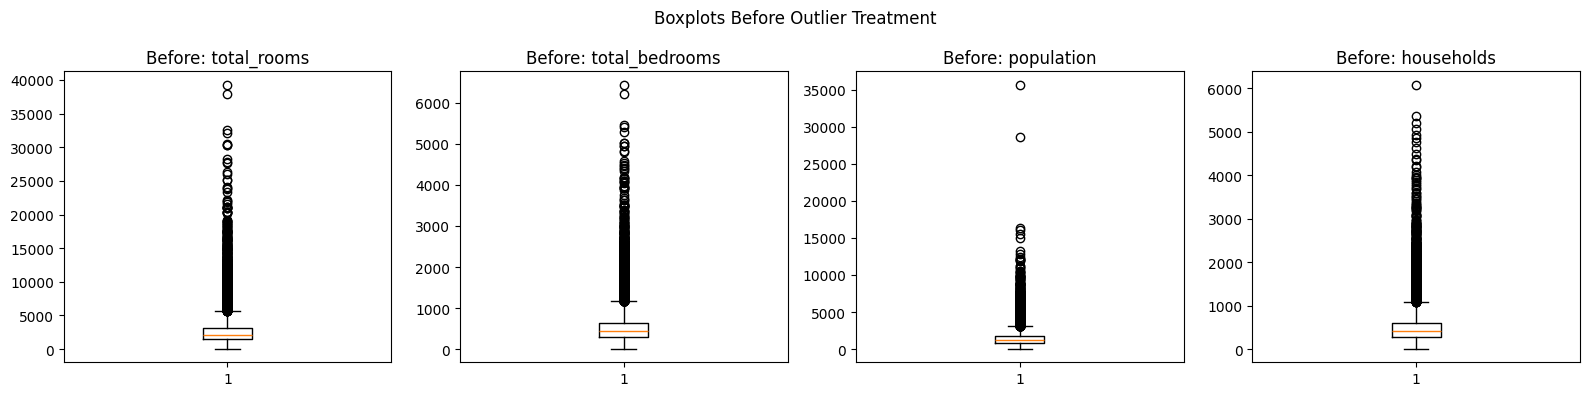

Dataset shape after outlier treatment: (19675, 11)


In [19]:
# Visualise outliers before treatment
cols_to_cap = ['total_rooms', 'total_bedrooms', 'population', 'households']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(cols_to_cap):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Before: {col}')
plt.suptitle("Boxplots Before Outlier Treatment")
plt.tight_layout()
plt.show()

# Apply IQR capping
for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

# Remove artificially capped house values
df = df[df['median_house_value'] < 500001]

print("Dataset shape after outlier treatment:", df.shape)

### 2C. Feature Scaling
Feature scaling transforms all numerical features to the same scale. We had this concidered because of the two reasons stated below.

1. For SVM, the algorithm relies on measuring distances between data points. If one feature has values in the thousands (like total_rooms) while another only has values in the tens (like median_income), the larger‑scaled feature will dominate the distance calculations. Scaling ensures that all features contribute fairly, regardless of their original scale.

2. For Lasso, the L1 regularization penalty is applied directly to feature coefficients. If features are on different scales, the penalty will affect them unevenly, which can bias feature selection. By scaling the data, we make sure the regularization is applied consistently across all features.

To achieve this, we used StandardScaler, which transforms each feature so that it has a mean of 0 and a standard deviation of 1. This keeps the model balanced and improves both fairness and accuracy.

### 2D. Feature Engineering

We created the following new features to give the models more meaningful information than raw counts alone:

| New Feature              | Formula                     | How helpful the new feature is                                                             |
|---------------------------|-----------------------------|-------------------------------------------------------------------------------|
| **rooms_per_household**   | total_rooms ÷ households    | Raw room counts don’t capture how spacious a block really is. For example, a block with 1,000 rooms spread across 500 households is very different from one with the same 1,000 rooms but only 50 households |
| **bedrooms_per_room**     | total_bedrooms ÷ total_rooms| Indicates the type of housing a high ratio suggests smaller, denser units which tend to be lower value |
| **population_per_household** | population ÷ households  | Measures household crowding. Overcrowded blocks tend to have lower property values |
| **log_median_income**     | log(1 + median_income)      | Income is heavily right-skewed. Log transformation compresses extreme values and improves model linearity |
| **income_category**       | Binned median_income        | Captures non-linear income effects by grouping into Low, Medium, High, Very High bands |


In [21]:
# Feature Engineering
# Ratio features
df['rooms_per_household']      = df['total_rooms'] / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# Log transformation on skewed columns
df['log_median_income'] = np.log1p(df['median_income'])

# Income category binning
df['income_category'] = pd.cut(
    df['median_income'],
    bins=[0, 2, 5, 10, np.inf],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("New features added successfully.")
print(df[['rooms_per_household', 'bedrooms_per_room', 
          'population_per_household', 'log_median_income', 
          'income_category']].head())

New features added successfully.
   rooms_per_household  bedrooms_per_room  population_per_household  \
0             6.984127           0.146591                  2.555556   
1             5.215904           0.194090                  2.197712   
2             8.288136           0.129516                  2.802260   
3             5.817352           0.184458                  2.547945   
4             6.281853           0.172096                  2.181467   

   log_median_income income_category  
0           2.232720            High  
1           2.230165            High  
2           2.111110            High  
3           1.893579            High  
4           1.578195          Medium  


### 2E. Encoding and Feature Selection

ocean_proximity and income_category are categorical columns. Machine 
learning models cannot process text, so we converted them to numbers using 
One-Hot Encoding, this creates a separate binary (0/1) column for each 
category value.

After encoding, we removed features with low correlation to median_house_value 
(below 0.05) as they contribute little predictive power and add noise.

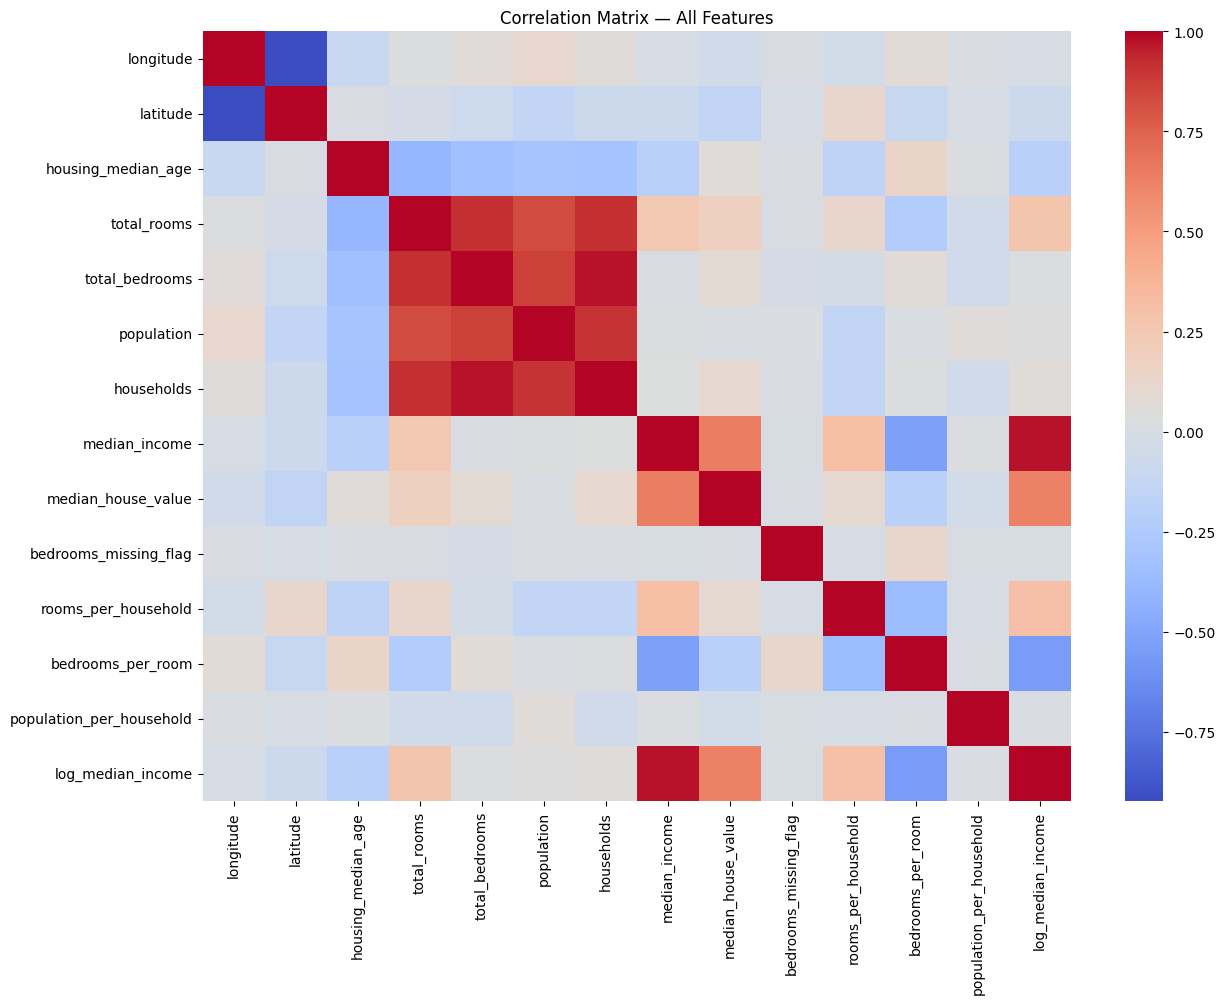

Features selected after correlation filtering:
['latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'log_median_income']


In [22]:
# Encoding + Feature Selection

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['ocean_proximity', 'income_category'], drop_first=True)

# Correlation-based feature selection
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix — All Features")
plt.show()

# Keep only features correlated with target above threshold
corr_target = numeric_df.corr()['median_house_value'].abs()
selected_features = corr_target[corr_target > 0.05].index
df = df[selected_features]

print("Features selected after correlation filtering:")
print(df.columns.tolist())

### 2F. Train-Test Split

We split the dataset into 80% training and 20% test sets.

1. The training set is what the model learns from  
2. The test set is kept completely separate and only used to evaluate how well the model performs on unseen data

We used the  80/20 split because it is the most widely used ratio in machine learning. It gives 
the model enough data to learn meaningful patterns (80%) while retaining a 
sufficient set (20%) to produce reliable evaluation metrics. 
With over 20,000 records in this dataset, 20% gives us approximately 4,000 
test samples  which are enough for evaluation.

In [23]:
# Feature Scaling + Train-Test Split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

Training set size: (15740, 9)
Test set size:     (3935, 9)


## Milestone 3: Regression Using Lasso
### 3A. Training the Lasso Regression Model  
Lasso Regression (Least Absolute Shrinkage and Selection Operator) extends ordinary linear regression by adding an L1 regularization penalty to the loss function. This penalty discourages large coefficients and forces coefficients of weak or redundant features to shrink to exactly zero, effectively performing automatic feature selection during training.

The strength of regularization is controlled by the alpha (λ) parameter:

A high alpha applies a stronger penalty, more features are eliminated, the model is simpler but may underfit
A low alpha applies a weaker penalty, more features are retained, the model is more complex but may overfit
Rather than manually guessing alpha, we used LassoCV which automatically tests multiple alpha values using 5-fold cross-validation and selects the one that produces the best generalisation performance.

In [24]:
# Train Lasso Regression

# Train with cross-validation to find best alpha
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train, y_train)

print("Optimal alpha (λ) selected by cross-validation:", round(lasso.alpha_, 4))

Optimal alpha (λ) selected by cross-validation: 62.1181


### 3B. Model Coefficients
After training, each feature is assigned a coefficient that represents its influence on the predicted house price:

A positive coefficient means the feature increases predicted price
A negative coefficient means the feature decreases predicted price
A zero coefficient means Lasso eliminated that feature entirely, it contributed no useful predictive information  
This  tells the prediction and which features matter most.

All feature coefficients:
total_rooms           -38683.421482
latitude               -5381.803410
log_median_income        747.983449
rooms_per_household     1288.569606
bedrooms_per_room       6820.173642
households             17698.339030
housing_median_age     22434.118983
total_bedrooms         32870.529995
median_income          77941.848973
dtype: float64

Features eliminated by Lasso (coefficient = 0):
[]


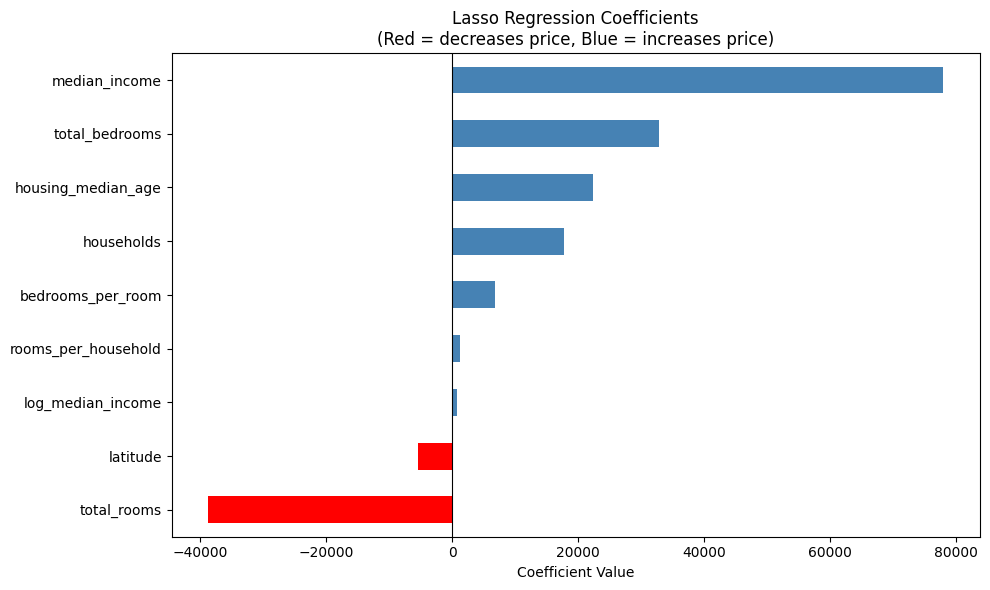

In [25]:
# Coefficients

coef = pd.Series(lasso.coef_, index=X.columns).sort_values()

print("All feature coefficients:")
print(coef)

print("\nFeatures eliminated by Lasso (coefficient = 0):")
print(coef[coef == 0].index.tolist())

# Visualise coefficients
plt.figure(figsize=(10, 6))
coef.plot(kind='barh', color=['red' if c < 0 else 'steelblue' for c in coef])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Lasso Regression Coefficients\n(Red = decreases price, Blue = increases price)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

### 3C. Model Evaluation

We evaluated the Lasso model using four standard regression metrics:

- MAE (Mean Absolute Error):
  The average dollar amount by which our predictions are off. Easy to interpret — same unit as the target.
- MSE (Mean Squared Error):
  Like MAE but squares the errors first, which penalises large mistakes more heavily.
- RMSE (Root Mean Squared Error):
  The square root of MSE, bringing it back to dollar units. More sensitive to large errors than MAE.
- R² Score:
  Tells us what proportion of the variation in house prices our model explains. A score of 1.0 is perfect, 0.0 means the model is no better than simply predicting the average price every time.

In [26]:
# Evaluation Metrics
y_pred = lasso.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print(f"MAE  (Mean Absolute Error):  ${mae:,.2f}")
print(f"MSE  (Mean Squared Error):   ${mse:,.2f}")
print(f"RMSE (Root Mean Sq. Error):  ${rmse:,.2f}")
print(f"R²   Score:                  {r2:.4f}")
print("=" * 40)

MAE  (Mean Absolute Error):  $52,275.30
MSE  (Mean Squared Error):   $4,740,438,732.89
RMSE (Root Mean Sq. Error):  $68,850.84
R²   Score:                  0.5246


### 3D. Actual vs Predicted Visualisation  
The scatter plot shows how the model’s predicted house prices compare to the actual values in the test set. Each dot represents a single housing block.

The red diagonal line marks the ideal case, a perfect prediction. Dots that fall exactly on this line mean the model got the price right. When dots cluster closely around the line, it indicates strong performance. Dots that sit farther away highlight blocks where the model struggled to predict accurately.

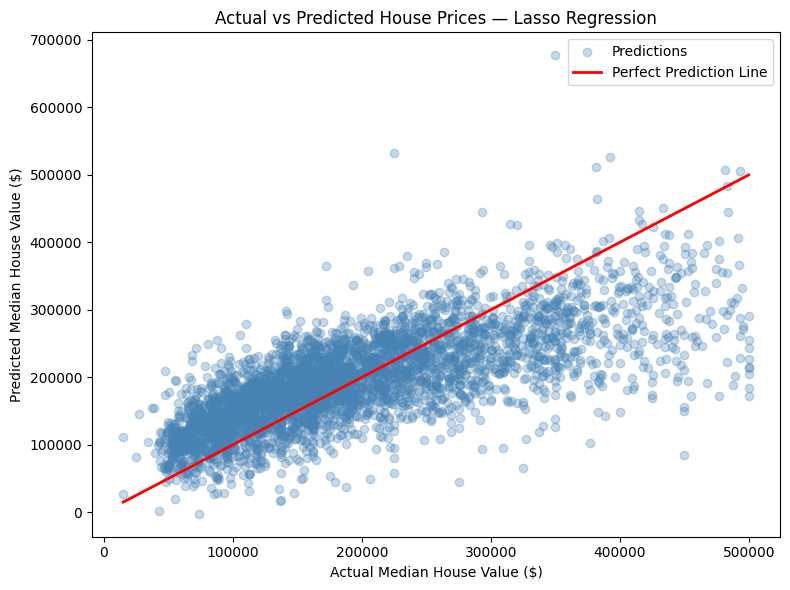

In [27]:
# Actual vs Predicted Plot (scatter plot)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', label='Predictions')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linewidth=2, label='Perfect Prediction Line'
)
plt.xlabel("Actual Median House Value ($)")
plt.ylabel("Predicted Median House Value ($)")
plt.title("Actual vs Predicted House Prices — Lasso Regression")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Results

Our Lasso model achieved an R² of 0.5246, meaning it explains approximately 52.5% of the variation in house prices across the test set. The RMSE  tells us that on average, our predictions are off by roughly $68,850 in dollar terms.


The model performed moderately given the complexity of housing price prediction. The scatter plot shows predictions clustering reasonably close to 
the perfect prediction line, though notable deviation is visible at higher price ranges. This suggests that the model underestimates premium properties. This is a common limitation of linear models when applied to data with non-linear relationships.

The feature with the largest positive influence on house price was median_income (coefficient: +77,942), confirming that neighbourhood income is the strongest driver of property value. total_bedrooms (+32,870) and housing_median_age (+22,434) also positively influenced price. However, total_rooms had the largest negative coefficient (-38,684), which reflects that raw room counts without household contextcan be misleading.

No features were eliminated entirely by Lasso, all 9 features retained non-zero coefficients, suggesting each contributes meaningful predictive information after feature engineering and selection were applied.

## Milestone 4: Classification Using Support Vector Machine (SVM)

### 4A. Creating Price Categories & Training SVM

Before training, we converted median_house_value into three price categories using the thresholds defined in Milestone 1:

| Category | Price Range |
|---|---|
| Low | $0 – $150,000 |
| Medium | $150,001 – $300,000 |
| High | Above $300,000 |

We then trained two SVM classifiers using different kernel functions to compare their performance:

- Linear Kernel: Attempts to separate the three price classes using  straight hyperplanes in feature space. Best when classes are roughly   linearly separable.
  
- RBF Kernel (Radial Basis Function): Maps data into a higher dimensional space to find curved decision boundaries. Better at capturing complex, non-linear relationships between features and price categories.

The C parameter controls the trade-off between maximising the margin and minimising misclassification:
- High C: The model tries hard to classify every training point   correctly, resulting in a narrower margin (risk of overfitting)
- Low C: The model allows some misclassifications in exchange for a wider, more generalised margin

In [29]:
# Create Price Categories 

# Recreate target from original values

# using the original y values before scaling
bins   = [0, 150000, 300000, np.inf]
labels = ['Low', 'Medium', 'High']

y_cat = pd.cut(y, bins=bins, labels=labels)

# Encode categories as numbers (Low=1, Medium=2, High=0 — alphabetical)
le    = LabelEncoder()
y_svm = le.fit_transform(y_cat)

print("Price category distribution:")
print(pd.Series(y_cat).value_counts())

# Split (same X_scaled from Milestone 2)
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_scaled, y_svm, test_size=0.2, random_state=42
)

# Train Linear Kernel
print("\nTraining SVM with Linear kernel...")
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_svm, y_train_svm)
y_pred_linear = svm_linear.predict(X_test_svm)
print("Linear kernel training complete.")

# Train RBF Kernel
print("Training SVM with RBF kernel...")
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_svm, y_train_svm)
y_pred_rbf = svm_rbf.predict(X_test_svm)
print("RBF kernel training complete.")

Price category distribution:
median_house_value
Medium    9184
Low       7620
High      2871
Name: count, dtype: int64

Training SVM with Linear kernel...
Linear kernel training complete.
Training SVM with RBF kernel...
RBF kernel training complete.


### 4B. Model Evaluation  
We evaluated both SVM models using the four classification metrics below:

- Accuracy: The percentage of all predictions that were correct overall
- Precision: Of all blocks predicted as a certain class, how many actually belonged to that class? High precision means few false alarms.
- Recall: Of all blocks that actually belong to a class, how many did the model correctly identify? High recall means few missed cases.
- F1-Score: The balanced average of Precision and Recall. Useful when classes are imbalanced — a single number summarising both.

  We also examine the Confusion Matrix which shows exactly where the model is making mistakes which classes it is confusing with each other.


  SVM Linear Kernel
Accuracy:           0.6892
Precision (macro):  0.7383
Recall (macro):     0.5980
F1-Score (macro):   0.6181

Classification Report:

              precision    recall  f1-score   support

        High       0.81      0.27      0.40       608
         Low       0.78      0.71      0.74      1545
      Medium       0.62      0.82      0.71      1782

    accuracy                           0.69      3935
   macro avg       0.74      0.60      0.62      3935
weighted avg       0.71      0.69      0.67      3935



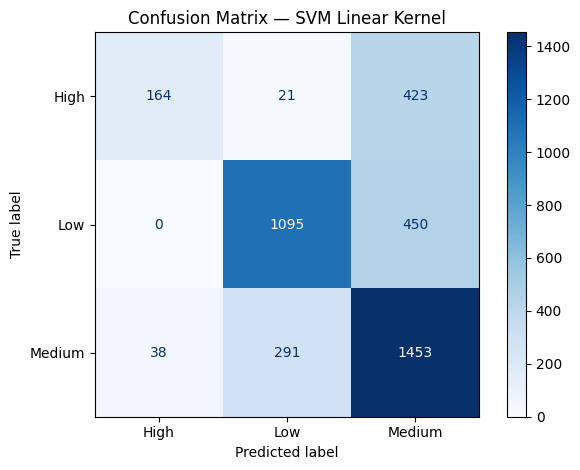


  SVM RBF Kernel
Accuracy:           0.7070
Precision (macro):  0.7475
Recall (macro):     0.6248
F1-Score (macro):   0.6481

Classification Report:

              precision    recall  f1-score   support

        High       0.81      0.33      0.47       608
         Low       0.78      0.74      0.76      1545
      Medium       0.65      0.81      0.72      1782

    accuracy                           0.71      3935
   macro avg       0.75      0.62      0.65      3935
weighted avg       0.73      0.71      0.70      3935



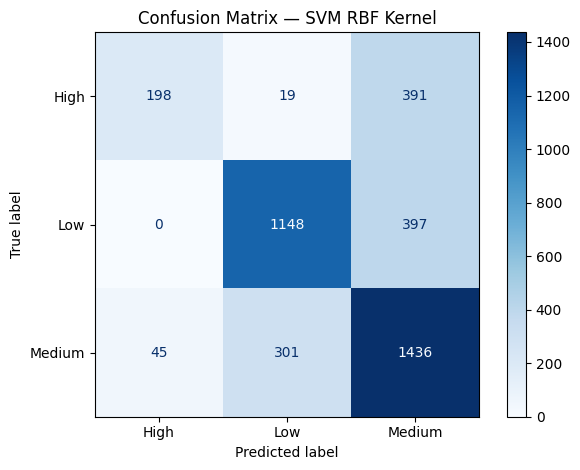

In [30]:
# Evaluation Function

def evaluate_svm(y_true, y_pred, model_name):
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy:           {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision (macro):  {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall (macro):     {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1-Score (macro):   {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    # Confusion matrix plot
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

evaluate_svm(y_test_svm, y_pred_linear, "SVM Linear Kernel")
evaluate_svm(y_test_svm, y_pred_rbf,    "SVM RBF Kernel")

### 4C. Interpretation of Results
SVM Linear Kernel: The linear SVM achieved an accuracy of 68.92% and a macro F1-score of 0.6181. It performed well on the Low and Medium classes (F1 of 0.74 and 0.71 respectively) but struggled significantly with the High class, achieving only an F1-score of 0.40. This is because the High class has far fewer samples (608 vs 1,545 Low and 1,782 Medium), making it harder for the model to learn its boundary.

SVM RBF Kernel: The RBF kernel achieved an accuracy of 70.70% and a macro F1-score of 0.6481, outperforming the linear kernel on every metric. This confirms that the relationship between housing features and price categories is non-linear, the RBF kernel's ability to draw curved boundaries gives it an advantage over the straight-line approach of the linear kernel.

False Positives and False Negatives: The most problematic class is High, where recall is only 0.27 (Linear) and 0.33 (RBF). This means the model misses approximately 70% of genuinely high-cost blocks, these are false negatives. In practice, this could cause investors or developers to overlook premium properties. The most common confusion is between Medium and High categories, which is understandable as their price boundaries are less distinct than Low vs Medium. A false positive for High, predicting a block as high-cost when it is actually medium-cost, could mislead urban planners into misallocating housing subsidies.